# Audi Q4 e-tron — Daily Deal Finder

**Goal:** Apply the two trained ML models to today's fresh scrape to identify listings that are:
1. **Underpriced** — listed below the model's predicted fair market value
2. **Fast-moving** — high predicted probability of selling within 14 days

**Business logic:** Buy underpriced listings → resell at predicted fair market value = profit margin.  
**Deal score** = `discount_eur × sale_probability_14d`

**Run order:** Run `02_price_prediction_model.ipynb` **and** `01_time_to_sell_model.ipynb` first.

---

**Output columns:**
- `price_eur` — actual listed price
- `predicted_fair_price` — model's estimate of true market value
- `discount_eur` — gross margin if bought at listed price and sold at fair value
- `discount_pct` — discount relative to fair value
- `sale_prob_14d` — probability sold/removed within 14 days
- `deal_score` — combined ranking metric
- `listing_url` — direct link to listing

In [1]:
# ── 1. Dependencies ────────────────────────────────────────────────────────────
import subprocess, sys
for pkg in ['scikit-learn', 'xgboost', 'lightgbm', 'shap']:
    try:
        __import__(pkg.replace('-', '_').split('[')[0])
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import warnings, json, re
from pathlib import Path
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (13, 5)

MODELS_DIR  = Path('saved_models')
SCRAPE_DIR  = Path('../Scrape')
OUTPUT_DIR  = Path('.')

# Deal filter thresholds (adjust as needed)
MIN_DISCOUNT_EUR   = 500     # minimum gross margin in €
MIN_SALE_PROB      = 0.50    # minimum predicted 14-day sale probability
MIN_PRICE_EUR      = 15_000  # exclude junk/outlier listings

# Check required model files exist
required_files = [
    MODELS_DIR / 'price_model_best1.pkl',
    MODELS_DIR / 'price_model_meta.json',
    MODELS_DIR / 'sale_model_best1.pkl',
    MODELS_DIR / 'sale_model_meta.json',
]
missing = [f for f in required_files if not f.exists()]
if missing:
    raise FileNotFoundError(
        f'Missing model files: {missing}\n'
        'Run 02_price_prediction_model.ipynb and 01_time_to_sell_model.ipynb first.'
    )

print('All imports and model files OK.')


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


All imports and model files OK.


## 1. Load Latest Daily Scrape

In [2]:
# Auto-detect most recently modified secondary CSV
secondary_csvs = sorted(
    [p for p in SCRAPE_DIR.glob('scrape_audi_q4_*_secondary.csv')],
    key=lambda p: p.stat().st_mtime,
    reverse=True
)

if not secondary_csvs:
    raise FileNotFoundError(
        f'No scrape_audi_q4_*_secondary.csv found in {SCRAPE_DIR.resolve()}'
    )

latest_csv = secondary_csvs[0]
raw_df     = pd.read_csv(latest_csv, dtype=str, low_memory=False)

print(f'Loaded: {latest_csv.name}')
print(f'Shape:  {raw_df.shape[0]} listings × {raw_df.shape[1]} columns')
print(f'\nAll available files (newest first):')
for p in secondary_csvs[:5]:
    print(f'  {p.name}')

Loaded: scrape_audi_q4_20260514_secondary.csv
Shape:  1365 listings × 57 columns

All available files (newest first):
  scrape_audi_q4_20260514_secondary.csv
  scrape_audi_q4_20260513_secondary.csv
  scrape_audi_q4_20260512_secondary.csv
  scrape_audi_q4_20260511_secondary.csv
  scrape_audi_q4_20260509_secondary.csv


## 2. Feature Engineering for New Listings

Replicates the preprocessing steps from `01_preprocessing_audi_q4_lifecycle.ipynb` but works on a raw daily CSV without requiring lifecycle columns.

In [3]:
def parse_number(series):
    """Extract first numeric sequence from a string series."""
    return pd.to_numeric(
        series.astype('string')
              .str.extract(r'([0-9][0-9,.]*)', expand=False)
              .str.replace(',', '', regex=False),
        errors='coerce'
    )


def parse_bool_col(series):
    return series.astype('string').str.lower().map({'true': True, 'false': False}).astype('boolean')


def engineer_features(df_raw, reference_date=None):
    """
    Apply the same feature transformations used in 01_preprocessing_audi_q4_lifecycle.ipynb
    to a raw daily secondary CSV.
    Returns a DataFrame ready for model prediction.
    """
    df = df_raw.copy()
    ref = reference_date or pd.Timestamp.today()

    # ── Numeric parsing ────────────────────────────────────────────────────────
    df['price_eur']               = parse_number(df.get('price', pd.Series(dtype=str)))
    df['mileage_km']              = parse_number(df.get('mileage', pd.Series(dtype=str)))
    df['electric_range_km']       = parse_number(df.get('electric_range', pd.Series(dtype=str)))
    df['electric_range_city_km']  = parse_number(df.get('electric_range_city', pd.Series(dtype=str)))
    df['battery_charging_time_min'] = parse_number(df.get('battery_charging_time', pd.Series(dtype=str)))
    df['warranty_months']         = parse_number(df.get('warranty_text', pd.Series(dtype=str)))

    for col in ['power_kw', 'power_hp', 'seller_rating_stars', 'seller_rating_count',
                'image_count', 'previous_owner_count', 'door_count', 'seat_count']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # ── Date → age ─────────────────────────────────────────────────────────────
    df['first_registration_dt'] = pd.to_datetime(
        '01/' + df['first_registration'].astype('string'),
        format='%d/%m/%Y', errors='coerce'
    )
    df['vehicle_age_months'] = (
        (ref.year  - df['first_registration_dt'].dt.year)  * 12
        + (ref.month - df['first_registration_dt'].dt.month)
    ).clip(lower=0)

    # ── Text-based binary flags ────────────────────────────────────────────────
    text = (
        df.get('title', pd.Series('')).fillna('') + ' ' +
        df.get('subtitle', pd.Series('')).fillna(''
    )).str.lower()

    df['is_sportback']   = df.get('variant', pd.Series('')).astype('string').str.strip().eq('Q4 e-tron Sportback')
    df['is_quattro']     = text.str.contains('quattro', regex=False)
    df['is_s_line']      = text.str.contains(r's line|s-line', regex=True)
    df['has_matrix']     = text.str.contains('matrix', regex=False)
    df['has_pano']       = text.str.contains(r'pano|panorama', regex=True)
    df['has_ahk']        = text.str.contains('ahk', regex=False)
    df['has_hud']        = text.str.contains(r'hud|head-up|head up', regex=True)
    df['has_acc']        = text.str.contains(r'\bacc\b', regex=True)
    df['has_camera']     = text.str.contains(r'kamera|camera|rfk', regex=True)

    # ── Model number ───────────────────────────────────────────────────────────
    df['model_number_v2'] = text.str.extract(
        r'(?:q4\s*)?(35|40|45|50|55)\s*(?:e[- ]?tron|quattro|qu\.|\b)',
        expand=False
    )

    # ── Derived ratio features ─────────────────────────────────────────────────
    df['mileage_per_month']  = df['mileage_km'] / df['vehicle_age_months'].replace(0, np.nan)
    df['price_per_kw']       = df['price_eur'] / df['power_kw'].replace(0, np.nan)
    df['price_per_hp']       = df['price_eur'] / df['power_hp'].replace(0, np.nan)
    df['price_per_range_km'] = df['price_eur'] / df['electric_range_km'].replace(0, np.nan)

    # ── Boolean columns ────────────────────────────────────────────────────────
    for raw_col, clean_col in [
        ('is_conditional_price', 'is_conditional_price_clean'),
        ('available_now',        'available_now_clean'),
        ('warranty_exists',      'warranty_exists_clean'),
        ('has_full_service_history', 'has_full_service_history_clean'),
        ('had_accident',         'had_accident_clean'),
    ]:
        src = raw_col if raw_col in df.columns else clean_col
        df[clean_col] = parse_bool_col(df.get(src, pd.Series(dtype=str)))

    # ── Indicator flags ────────────────────────────────────────────────────────
    df['seller_has_rating']    = df['seller_rating_stars'].notna().astype(int)
    df['has_warranty_months']  = df['warranty_months'].notna().astype(int)
    df['has_battery_info']     = df.get('battery_ownership', pd.Series(dtype=str)).notna().astype(int)
    df['has_city_range']       = df['electric_range_city_km'].notna().astype(int)
    df['has_charging_time']    = df['battery_charging_time_min'].notna().astype(int)
    df['duplicate_listing_id'] = df.get('listing_id', pd.Series(dtype=str)).duplicated(keep=False).astype(int)

    return df


print('Feature engineering function defined.')
df_eng = engineer_features(raw_df)
print(f'Engineered features shape: {df_eng.shape}')
print(f'Price stats (€):')
print(df_eng['price_eur'].describe().round(0))

Feature engineering function defined.
Engineered features shape: (1365, 90)
Price stats (€):
count     1365.0
mean     39614.0
std       9869.0
min      21999.0
25%      31640.0
50%      38405.0
75%      45990.0
max      79900.0
Name: price_eur, dtype: Float64


## 3. Load Models & Apply Predictions

In [4]:
# ── Load models and metadata ───────────────────────────────────────────────────
price_model = joblib.load(MODELS_DIR / 'price_model_best1.pkl')
sale_model  = joblib.load(MODELS_DIR / 'sale_model_best1.pkl')

with open(MODELS_DIR / 'price_model_meta.json') as f:
    price_meta = json.load(f)

with open(MODELS_DIR / 'sale_model_meta.json') as f:
    sale_meta = json.load(f)

PRICE_FEATURES = price_meta['feature_cols']
SALE_FEATURES  = sale_meta['feature_cols']
USE_LOG_PRICE  = price_meta.get('use_log_target', False)

print(f'Price model: {price_meta["best_model_name"]}  (CV RMSE €{price_meta["tuned_rmse_best"]:,.0f})')
print(f'Sale model:  {sale_meta["best_model_name"]}   (CV AUC {sale_meta["tuned_auc_best"]:.4f})')
print(f'\nPrice model features: {len(PRICE_FEATURES)}')
print(f'Sale model features:  {len(SALE_FEATURES)}')

Price model: LightGBM  (CV RMSE €3,084)
Sale model:  XGBoost   (CV AUC 0.7033)

Price model features: 42
Sale model features:  46


In [5]:
# ── Align features & run predictions ──────────────────────────────────────────
def align_features(df, feature_cols):
    """Select and type-coerce columns needed by a model; add missing cols as NaN."""
    result = pd.DataFrame(index=df.index)
    for col in feature_cols:
        if col in df.columns:
            result[col] = df[col]
        else:
            result[col] = np.nan
    return result


# Filter to listings with a valid price (needed for deal scoring)
valid_mask = df_eng['price_eur'].notna() & (df_eng['price_eur'] > MIN_PRICE_EUR)
df_valid   = df_eng[valid_mask].copy()
print(f'Valid listings (price > €{MIN_PRICE_EUR:,}): {len(df_valid)} of {len(df_eng)}')

# Predict fair market price
X_price = align_features(df_valid, PRICE_FEATURES)
y_price_raw = price_model.predict(X_price)
if USE_LOG_PRICE:
    df_valid['predicted_fair_price'] = np.expm1(y_price_raw)
else:
    df_valid['predicted_fair_price'] = y_price_raw

# Predict 14-day sale probability
X_sale  = align_features(df_valid, SALE_FEATURES)
df_valid['sale_prob_14d'] = sale_model.predict_proba(X_sale)[:, 1]

print(f'Predicted price range: €{df_valid["predicted_fair_price"].min():,.0f} – €{df_valid["predicted_fair_price"].max():,.0f}')
print(f'Sale prob range:       {df_valid["sale_prob_14d"].min():.3f} – {df_valid["sale_prob_14d"].max():.3f}')

Valid listings (price > €15,000): 1365 of 1365
Predicted price range: €22,146 – €74,224
Sale prob range:       0.036 – 0.951


## 4. Deal Score Computation

In [6]:
# ── Compute deal metrics ──────────────────────────────────────────────────────
df_valid['discount_eur'] = (
    df_valid['predicted_fair_price'] - df_valid['price_eur']
).round(0)

df_valid['discount_pct'] = (
    df_valid['discount_eur'] / df_valid['predicted_fair_price'] * 100
).round(1)

# Deal score: gross margin € × sale velocity (probability)
df_valid['deal_score'] = (
    df_valid['discount_eur'].clip(lower=0) * df_valid['sale_prob_14d']
).round(0)

# ── Apply deal filters ────────────────────────────────────────────────────────
deal_mask = (
    (df_valid['discount_eur'] > MIN_DISCOUNT_EUR) &
    (df_valid['sale_prob_14d'] > MIN_SALE_PROB) &
    (df_valid['predicted_fair_price'] > df_valid['price_eur'])
)

deals = df_valid[deal_mask].sort_values('deal_score', ascending=False).reset_index(drop=True)
deals.index = deals.index + 1  # rank starts at 1
deals.index.name = 'rank'

print(f'\nDeal filter summary')
print(f'  Total valid listings:           {len(df_valid)}')
print(f'  Discount > €{MIN_DISCOUNT_EUR}:           {(df_valid["discount_eur"] > MIN_DISCOUNT_EUR).sum()}')
print(f'  Sale prob > {MIN_SALE_PROB:.0%}:              {(df_valid["sale_prob_14d"] > MIN_SALE_PROB).sum()}')
print(f'  Both filters (deal candidates): {len(deals)}')

print(f'\nTop deal metrics:')
print(f'  Max discount:         €{deals["discount_eur"].max():,.0f}')
print(f'  Avg discount:         €{deals["discount_eur"].mean():,.0f}')
print(f'  Avg discount %:       {deals["discount_pct"].mean():.1f}%')
print(f'  Avg sale prob:        {deals["sale_prob_14d"].mean():.1%}')
print(f'  Total addressable margin: €{deals["discount_eur"].sum():,.0f}')


Deal filter summary
  Total valid listings:           1365
  Discount > €500:           240
  Sale prob > 50%:              320
  Both filters (deal candidates): 76

Top deal metrics:
  Max discount:         €2,494
  Avg discount:         €1,048
  Avg discount %:       2.5%
  Avg sale prob:        67.4%
  Total addressable margin: €79,617


## 5. Deal Table — Top Opportunities

In [7]:
# ── Full deal table ───────────────────────────────────────────────────────────
DISPLAY_COLS = [
    'title', 'price_eur', 'predicted_fair_price',
    'discount_eur', 'discount_pct', 'sale_prob_14d', 'deal_score',
    'model_number_v2', 'variant',
    'mileage_km', 'vehicle_age_months', 'power_kw',
    'city', 'seller_name', 'seller_type',
    'listing_url',
]
DISPLAY_COLS = [c for c in DISPLAY_COLS if c in deals.columns]

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.0f}' if abs(x) >= 10 else f'{x:.3f}')

print(f'Top 30 Deal Candidates (of {len(deals)} total):')
display_df = deals[DISPLAY_COLS].head(30)
display_df['price_eur']            = display_df['price_eur'].map(lambda x: f'€{x:,.0f}')
display_df['predicted_fair_price'] = display_df['predicted_fair_price'].map(lambda x: f'€{x:,.0f}')
display_df['discount_eur']         = display_df['discount_eur'].map(lambda x: f'€{x:,.0f}')
display_df['discount_pct']         = display_df['discount_pct'].map(lambda x: f'{x:.1f}%')
display_df['sale_prob_14d']        = display_df['sale_prob_14d'].map(lambda x: f'{x:.1%}')
display_df['deal_score']           = display_df['deal_score'].map(lambda x: f'{x:,.0f}')
display_df

Top 30 Deal Candidates (of 76 total):


,title,price_eur,predicted_fair_price,discount_eur,discount_pct,sale_prob_14d,deal_score,model_number_v2,variant,mileage_km,vehicle_age_months,power_kw,city,seller_name,seller_type,listing_url
rank,,,,,,,,,,,,,,,,
1,Audi Q4 e-tron 55 quattro - S LINE - AHK - MATRIX -,"€47,890","€50,384","€2,494",4.9%,94.8%,"2,363",55,Q4 e-tron,9950,28,250,Burgoberbach,Audi Burgoberbach | Feser-Graf,Dealer,https://www.autoscout24.com/offers/audi-q4-e-tron-55-qua...
2,Audi Q4 e-tron 55 qu. - AHK - S LINE - MATRIX - ACC,"€47,890","€49,752","€1,862",3.7%,88.4%,"1,646",55,Q4 e-tron,6050,28,250,Burgoberbach,Audi Burgoberbach | Feser-Graf,Dealer,https://www.autoscout24.com/offers/audi-q4-e-tron-55-qu-...
3,Audi Q4 e-tron 55 qu 2x S line AHK MATRIX 360° WÄRMEPUMPE,"€47,980","€49,711","€1,731",3.5%,95.1%,"1,646",55,Q4 e-tron,9850,27,250,Schwabach,Feser GmbH,Dealer,https://www.autoscout24.com/offers/audi-q4-e-tron-55-qu-...
4,Audi Q4 e-tron S-Line 55 qu. AHK/21''/P-Dach/W-Pumpe,"€48,980","€50,859","€1,879",3.7%,85.0%,"1,598",55,Q4 e-tron,9970,26,250,Neumarkt,Fischer Automobile GmbH,Dealer,https://www.autoscout24.com/offers/audi-q4-e-tron-s-line...
5,Audi Q4 e-tron 40 basis Navi/Einparkhi/LED,"€27,190","€29,070","€1,880",6.5%,77.2%,"1,452",40,Q4 e-tron,64500,38,150,Wolfsburg,Audi Zentrum Wolfsburg GmbH,Dealer,https://www.autoscout24.com/offers/audi-q4-e-tron-40-bas...
6,Audi Q4 e-tron 55 qu. S line Dinamica/Sonos/20''/360,"€45,880","€47,738","€1,858",3.9%,77.6%,"1,441",55,Q4 e-tron,7271,28,250,Ursensollen,Fischer Automobile GmbH & Co. KG,Dealer,https://www.autoscout24.com/offers/audi-q4-e-tron-55-qu-...
7,Audi Q4 e-tron Q4 SUV e-tron NEUBESTELLUNG MJ 2027,"€38,590","€40,570","€1,980",4.9%,70.5%,"1,395",NaN,Q4 e-tron,0,NaN,150,Kassel,Audi Zentrum Kassel GmbH & Co.KG,Dealer,https://www.autoscout24.com/offers/audi-q4-e-tron-q4-suv...
8,Audi Q4 e-tron 45 qu. advanced Matrix/Leder/SONOS,"€48,989","€50,619","€1,630",3.2%,83.3%,"1,357",45,Q4 e-tron,8727,7.000,210,Eching,Audi München GmbH,Dealer,https://www.autoscout24.com/offers/audi-q4-e-tron-45-qu-...
9,Audi Q4 e-tron 50 qu S line*Navi*Matrix*SON,"€39,480","€40,796","€1,316",3.2%,87.4%,"1,150",50,Q4 e-tron Sportback,19294,36,220,Oberursel,Audi Zentrum Bad Homburg/Oberursel,Dealer,https://www.autoscout24.com/offers/audi-q4-e-tron-50-qu-...


## 6. Visualizations — Deal Opportunity Matrix

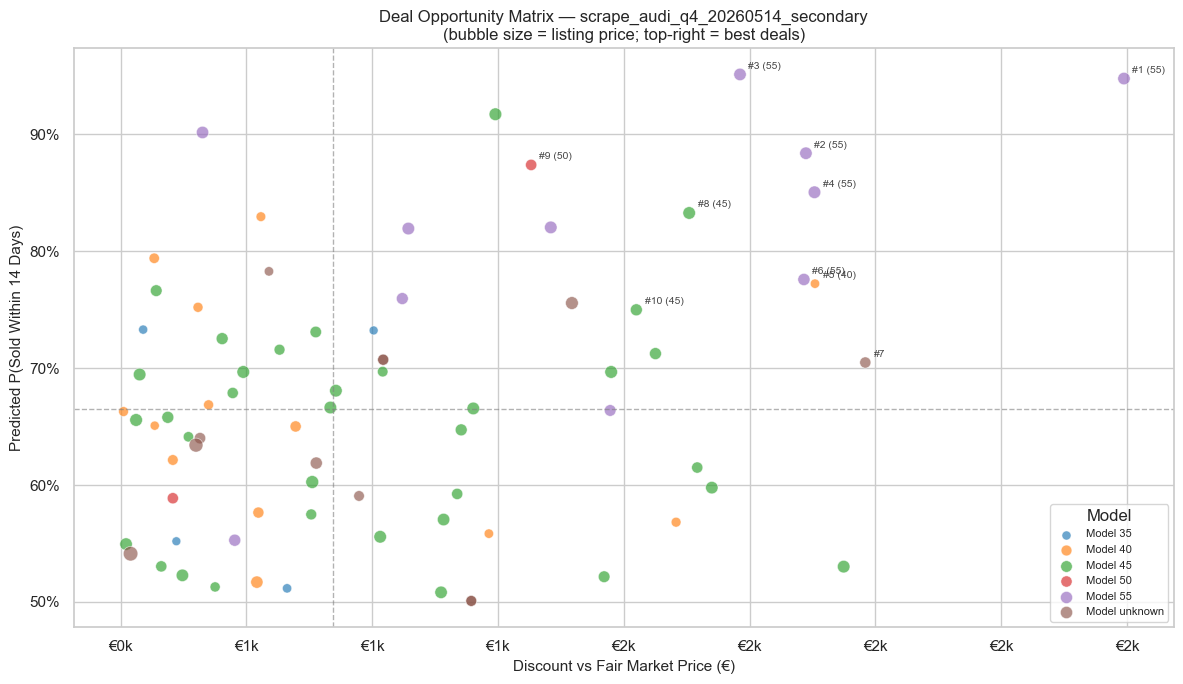

In [8]:
# ── 1. Deal Opportunity Matrix (bubble chart) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Color by model_number_v2
model_col = 'model_number_v2' if 'model_number_v2' in deals.columns else None
if model_col and deals[model_col].notna().any():
    groups = deals[model_col].fillna('unknown').unique()
    palette = dict(zip(sorted(groups), sns.color_palette('tab10', len(groups))))
    for grp, color in palette.items():
        mask = deals[model_col].fillna('unknown') == grp
        sub  = deals[mask]
        ax.scatter(
            sub['discount_eur'], sub['sale_prob_14d'],
            s=sub['price_eur'] / 600,
            alpha=0.65, color=color, label=f'Model {grp}', edgecolors='white', lw=0.5
        )
else:
    ax.scatter(
        deals['discount_eur'], deals['sale_prob_14d'],
        s=deals['price_eur'] / 600, alpha=0.6, color='#4C78A8',
        edgecolors='white', lw=0.5
    )

# Quadrant lines
ax.axvline(deals['discount_eur'].median(), color='gray', lw=1, linestyle='--', alpha=0.6)
ax.axhline(deals['sale_prob_14d'].median(), color='gray', lw=1, linestyle='--', alpha=0.6)

# Label top 10 deals
for i, row in deals.head(10).iterrows():
    lbl = f'#{i}'
    if 'model_number_v2' in row and pd.notna(row['model_number_v2']):
        lbl += f' ({row["model_number_v2"]})'
    ax.annotate(
        lbl,
        (row['discount_eur'], row['sale_prob_14d']),
        textcoords='offset points', xytext=(6, 4),
        fontsize=7.5, alpha=0.85
    )

ax.set_xlabel('Discount vs Fair Market Price (€)', fontsize=11)
ax.set_ylabel('Predicted P(Sold Within 14 Days)', fontsize=11)
ax.set_title(
    f'Deal Opportunity Matrix — {latest_csv.stem}\n'
    '(bubble size = listing price; top-right = best deals)',
    fontsize=12
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
if model_col:
    ax.legend(title='Model', fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

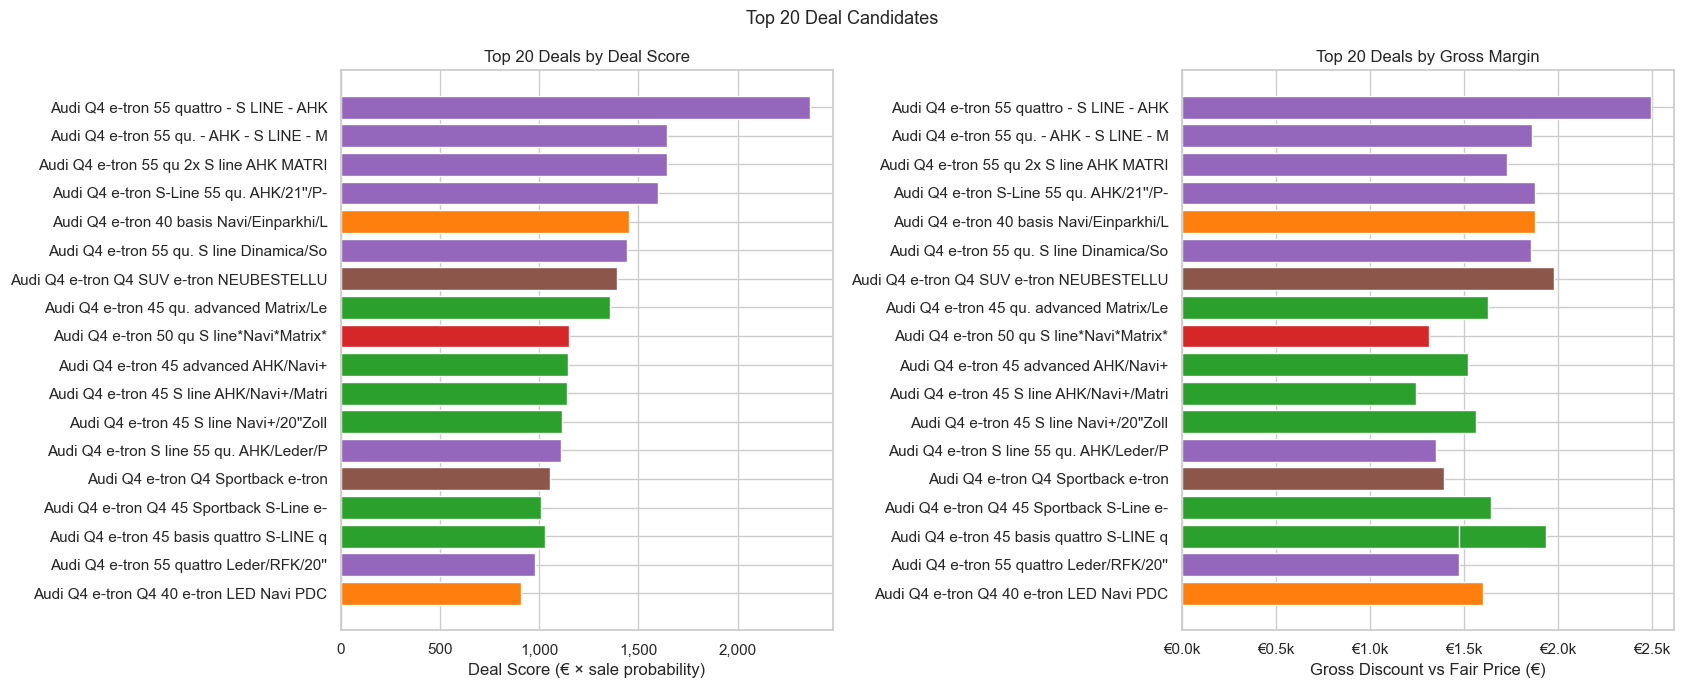

In [9]:
# ── 2. Top 20 Deals by Deal Score (bar chart) ────────────────────────────────
top20 = deals.head(20).copy()
label_col = 'title' if 'title' in top20.columns else top20.index.astype(str)

if 'title' in top20.columns:
    top20['label'] = top20['title'].str[:40].fillna(f'Rank {top20.index}')
else:
    top20['label'] = [f'Rank {i}' for i in top20.index]

if model_col and model_col in top20.columns:
    groups_in_top20 = top20[model_col].fillna('unknown')
    colors_top20 = [palette.get(g, '#888888') for g in groups_in_top20]
else:
    colors_top20 = sns.color_palette('Blues_d', len(top20))

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

axes[0].barh(top20['label'][::-1], top20['deal_score'][::-1], color=colors_top20[::-1])
axes[0].set_xlabel('Deal Score (€ × sale probability)')
axes[0].set_title('Top 20 Deals by Deal Score')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].barh(top20['label'][::-1], top20['discount_eur'][::-1], color=colors_top20[::-1])
axes[1].set_xlabel('Gross Discount vs Fair Price (€)')
axes[1].set_title('Top 20 Deals by Gross Margin')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.1f}k'))

plt.suptitle('Top 20 Deal Candidates', fontsize=13)
plt.tight_layout()
plt.show()

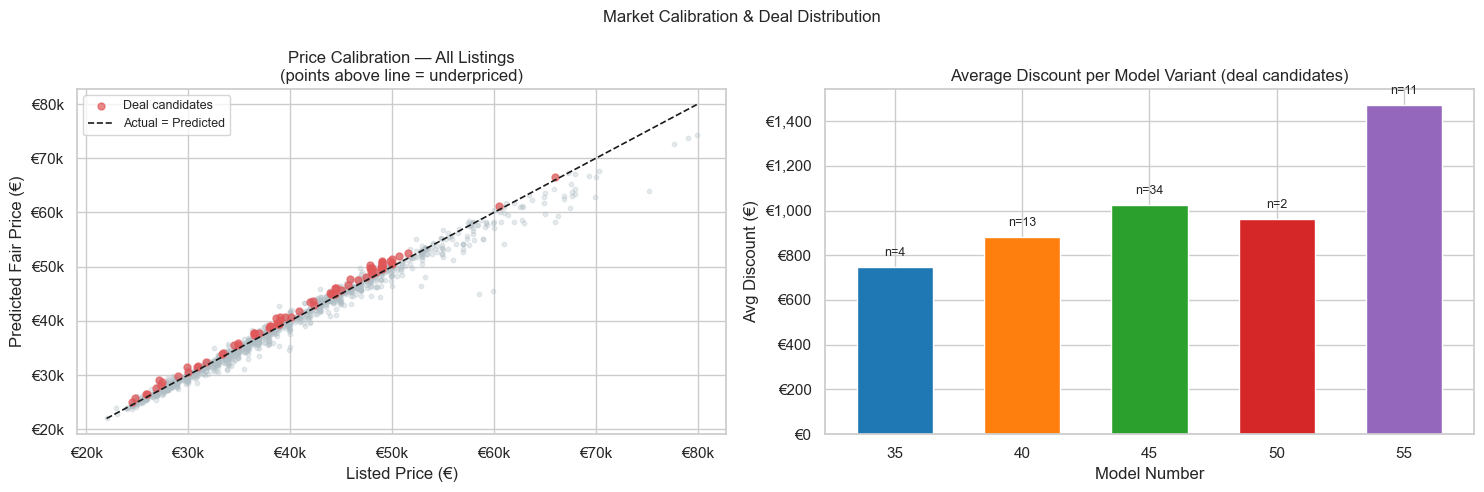

In [10]:
# ── 3. Market calibration: predicted vs actual price (all valid listings) ─────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# All listings
axes[0].scatter(
    df_valid['price_eur'], df_valid['predicted_fair_price'],
    alpha=0.3, s=10, color='#B0BEC5'
)
# Deals highlighted
axes[0].scatter(
    deals['price_eur'], deals['predicted_fair_price'],
    alpha=0.7, s=25, color='#E15759', label='Deal candidates'
)
lims = [min(df_valid['price_eur'].min(), df_valid['predicted_fair_price'].min()),
        max(df_valid['price_eur'].max(), df_valid['predicted_fair_price'].max())]
axes[0].plot(lims, lims, 'k--', lw=1.2, label='Actual = Predicted')
axes[0].set_xlabel('Listed Price (€)'); axes[0].set_ylabel('Predicted Fair Price (€)')
axes[0].set_title('Price Calibration — All Listings\n(points above line = underpriced)')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))

# Deal score by model variant
if model_col and model_col in deals.columns and deals[model_col].notna().any():
    deal_by_model = deals.groupby(model_col).agg(
        deal_count=('deal_score', 'count'),
        avg_discount=('discount_eur', 'mean'),
        avg_sale_prob=('sale_prob_14d', 'mean'),
    ).sort_index()
    colors_model = [palette.get(str(g), '#888888') for g in deal_by_model.index]
    deal_by_model['avg_discount'].plot(kind='bar', ax=axes[1], color=colors_model, width=0.6)
    axes[1].set_title('Average Discount per Model Variant (deal candidates)')
    axes[1].set_xlabel('Model Number'); axes[1].set_ylabel('Avg Discount (€)')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
    axes[1].tick_params(axis='x', rotation=0)
    for i, (idx, row) in enumerate(deal_by_model.iterrows()):
        axes[1].text(i, row['avg_discount'] + 50, f'n={row["deal_count"]}', ha='center', fontsize=9)
else:
    sns.histplot(deals['discount_eur'], bins=20, ax=axes[1], color='#E15759')
    axes[1].set_title('Discount Distribution — Deal Candidates')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

plt.suptitle('Market Calibration & Deal Distribution', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# ── 4. Deal breakdown by model variant ────────────────────────────────────────
if model_col and model_col in deals.columns and deals[model_col].notna().any():
    print('Deal candidates by model variant:')
    variant_summary = deals.groupby(model_col, dropna=False).agg(
        count=('deal_score', 'count'),
        avg_price=('price_eur', 'mean'),
        avg_fair=('predicted_fair_price', 'mean'),
        avg_discount_eur=('discount_eur', 'mean'),
        avg_discount_pct=('discount_pct', 'mean'),
        avg_sale_prob=('sale_prob_14d', 'mean'),
        total_margin=('discount_eur', 'sum'),
    ).sort_index()
    variant_summary['avg_price']       = variant_summary['avg_price'].map(lambda x: f'€{x:,.0f}')
    variant_summary['avg_fair']        = variant_summary['avg_fair'].map(lambda x: f'€{x:,.0f}')
    variant_summary['avg_discount_eur']= variant_summary['avg_discount_eur'].map(lambda x: f'€{x:,.0f}')
    variant_summary['avg_discount_pct']= variant_summary['avg_discount_pct'].map(lambda x: f'{x:.1f}%')
    variant_summary['avg_sale_prob']   = variant_summary['avg_sale_prob'].map(lambda x: f'{x:.1%}')
    variant_summary['total_margin']    = variant_summary['total_margin'].map(lambda x: f'€{x:,.0f}')
    print(variant_summary.to_string())

Deal candidates by model variant:
                 count avg_price avg_fair avg_discount_eur avg_discount_pct avg_sale_prob total_margin
model_number_v2                                                                                       
35                   4   €25,494  €26,242             €748             2.9%         63.2%       €2,990
40                  13   €32,537  €33,418             €882             2.7%         66.3%      €11,462
45                  34   €44,423  €45,445           €1,023             2.3%         64.7%      €34,770
50                   2   €39,180  €40,140             €960             2.4%         73.1%       €1,920
55                  11   €46,810  €48,280           €1,470             3.0%         81.1%      €16,174
NaN                 12   €42,726  €43,751           €1,025             2.5%         64.0%      €12,301


## 7. SHAP Explanations for Top 5 Deals

Why does the price model predict each top deal is worth more than its asking price?


── Deal #1 ─────────────────────────────────────────────
  Title:     Audi Q4 e-tron 55 quattro - S LINE - AHK - MATRIX 
  Listed:    €47,890
  Fair val:  €50,384  (model prediction)
  Margin:    €2,494  (4.9% discount)
  Sale prob: 94.8%
  Deal score:2,363
  URL:       https://www.autoscout24.com/offers/audi-q4-e-tron-55-quattro-s-line-ahk-matrix-electric-grey-7ce1c043-e7e0-403b-8645-f39fb062b957


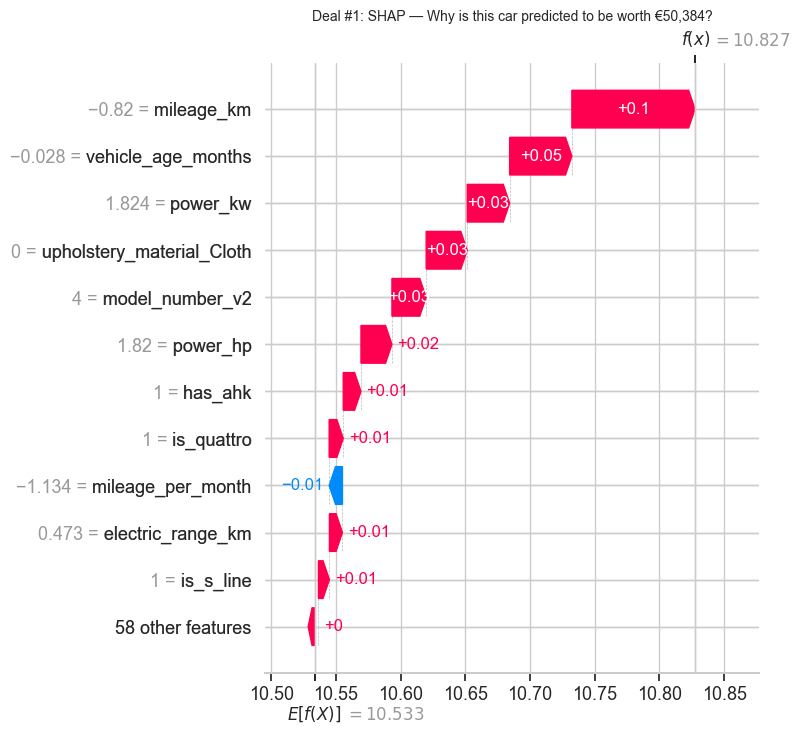


── Deal #2 ─────────────────────────────────────────────
  Title:     Audi Q4 e-tron 55 qu. - AHK - S LINE - MATRIX - AC
  Listed:    €47,890
  Fair val:  €49,752  (model prediction)
  Margin:    €1,862  (3.7% discount)
  Sale prob: 88.4%
  Deal score:1,646
  URL:       https://www.autoscout24.com/offers/audi-q4-e-tron-55-qu-ahk-s-line-matrix-acc-electric-blue-0735e305-4e89-4e1b-9b3e-ef9ddde1b857


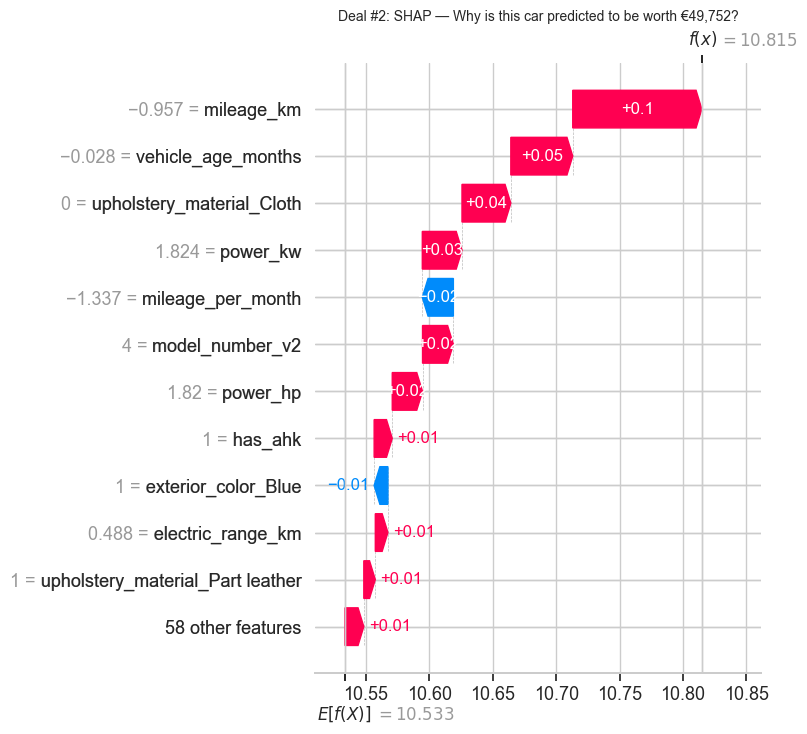


── Deal #3 ─────────────────────────────────────────────
  Title:     Audi Q4 e-tron 55 qu 2x S line AHK MATRIX 360° WÄR
  Listed:    €47,980
  Fair val:  €49,711  (model prediction)
  Margin:    €1,731  (3.5% discount)
  Sale prob: 95.1%
  Deal score:1,646
  URL:       https://www.autoscout24.com/offers/audi-q4-e-tron-55-qu-2x-s-line-ahk-matrix-360-waermepumpe-electric-grey-599047c8-d9c2-4e98-9614-2eaf9265dc0b


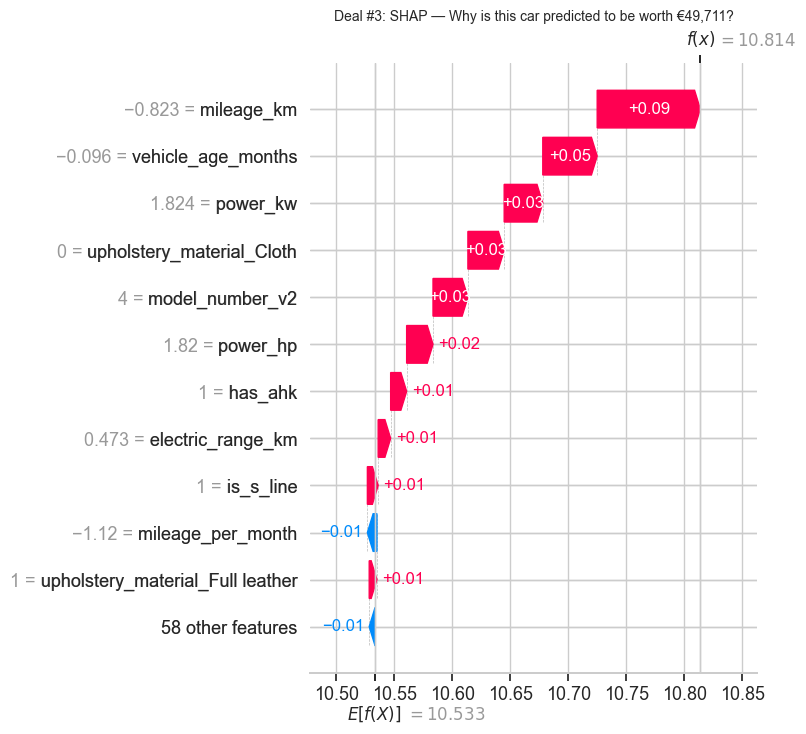


── Deal #4 ─────────────────────────────────────────────
  Title:     Audi Q4 e-tron S-Line 55 qu. AHK/21''/P-Dach/W-Pum
  Listed:    €48,980
  Fair val:  €50,859  (model prediction)
  Margin:    €1,879  (3.7% discount)
  Sale prob: 85.0%
  Deal score:1,598
  URL:       https://www.autoscout24.com/offers/audi-q4-e-tron-s-line-55-qu-ahk-21-p-dach-w-pumpe-electric-white-992c88f8-7c7b-48d1-83f3-600f1964fccb


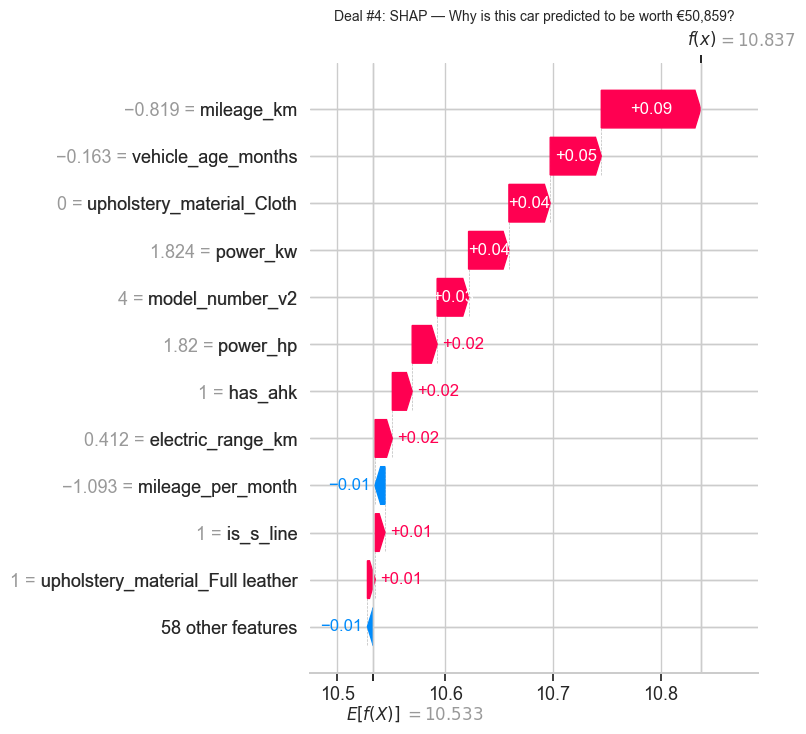


── Deal #5 ─────────────────────────────────────────────
  Title:     Audi Q4 e-tron 40 basis Navi/Einparkhi/LED
  Listed:    €27,190
  Fair val:  €29,070  (model prediction)
  Margin:    €1,880  (6.5% discount)
  Sale prob: 77.2%
  Deal score:1,452
  URL:       https://www.autoscout24.com/offers/audi-q4-e-tron-40-basis-navi-einparkhi-led-electric-black-31a3f491-aa01-4f19-9baf-c2a85726a782


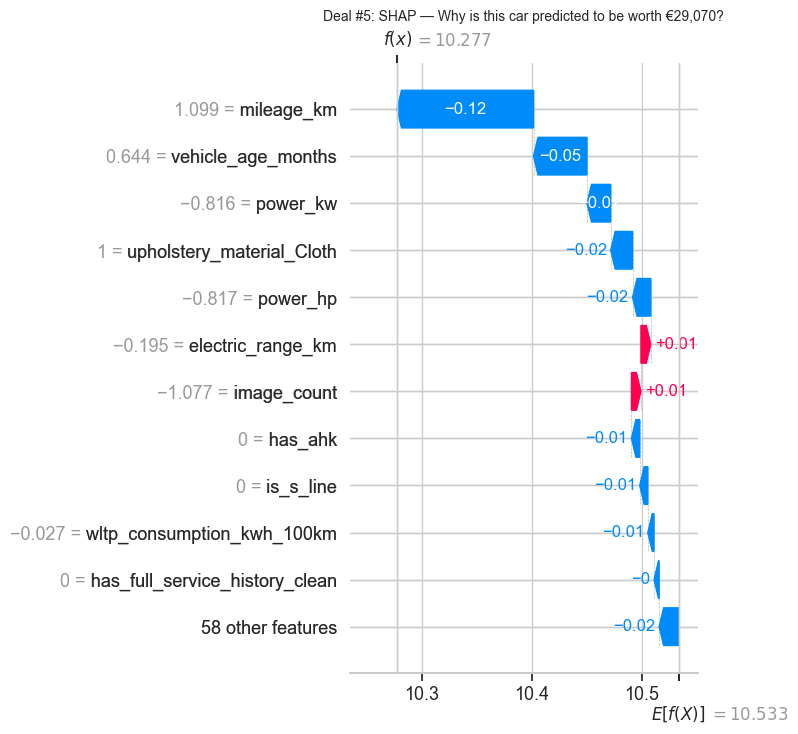

In [12]:
# ── SHAP explanations for top 5 deals (price model) ──────────────────────────
TOP_N_SHAP = min(5, len(deals))

if TOP_N_SHAP == 0:
    print('No deal candidates found — skip SHAP.')
else:
    top_deals = deals.head(TOP_N_SHAP)
    X_top_price = align_features(top_deals, PRICE_FEATURES)

    pre  = price_model.named_steps['pre']
    reg  = price_model.named_steps['reg']
    X_top_transformed = pre.transform(X_top_price)

    try:
        feat_names = [n.split('__')[-1] for n in pre.get_feature_names_out()]
    except Exception:
        feat_names = [f'f{i}' for i in range(X_top_transformed.shape[1])]

    model_class = type(reg).__name__
    if 'XGB' in model_class or 'LGBM' in model_class or 'Forest' in model_class:
        explainer   = shap.TreeExplainer(reg)
        shap_values = explainer.shap_values(X_top_transformed)
    else:
        explainer   = shap.LinearExplainer(reg, X_top_transformed)
        shap_values = explainer.shap_values(X_top_transformed)

    for i, (rank, row) in enumerate(top_deals.iterrows()):
        actual    = row['price_eur']
        predicted = row['predicted_fair_price']
        discount  = row['discount_eur']
        sale_p    = row['sale_prob_14d']
        title_str = str(row.get('title', 'N/A'))[:50]

        print(f'\n── Deal #{rank} ─────────────────────────────────────────────')
        print(f'  Title:     {title_str}')
        print(f'  Listed:    €{actual:,.0f}')
        print(f'  Fair val:  €{predicted:,.0f}  (model prediction)')
        print(f'  Margin:    €{discount:,.0f}  ({row["discount_pct"]:.1f}% discount)')
        print(f'  Sale prob: {sale_p:.1%}')
        print(f'  Deal score:{row["deal_score"]:,.0f}')
        if 'listing_url' in row:
            print(f'  URL:       {row["listing_url"]}')

        exp_i = shap.Explanation(
            values=shap_values[i],
            base_values=(explainer.expected_value if not isinstance(explainer.expected_value, (list, np.ndarray))
                         else explainer.expected_value[0]),
            data=X_top_transformed[i],
            feature_names=feat_names
        )
        plt.figure(figsize=(11, 5))
        shap.plots.waterfall(exp_i, max_display=12, show=False)
        plt.title(f'Deal #{rank}: SHAP — Why is this car predicted to be worth €{predicted:,.0f}?', fontsize=10)
        plt.tight_layout()
        plt.show()

## 8. Export Deal Report

In [13]:
# ── Export to CSV ─────────────────────────────────────────────────────────────
EXPORT_COLS = [
    'price_eur', 'predicted_fair_price', 'discount_eur', 'discount_pct',
    'sale_prob_14d', 'deal_score',
    'model_number_v2', 'variant', 'mileage_km', 'vehicle_age_months',
    'power_kw', 'electric_range_km',
    'city', 'seller_name', 'seller_type',
    'is_s_line', 'is_quattro', 'has_matrix', 'had_accident_clean',
    'listing_url', 'title',
]
EXPORT_COLS = [c for c in EXPORT_COLS if c in deals.columns]

today_str   = datetime.today().strftime('%Y%m%d')
output_path = OUTPUT_DIR / f'deal_report_{today_str}.csv'

deals[EXPORT_COLS].to_csv(output_path, index=True, index_label='rank')

print(f'Deal report saved to: {output_path}')
print(f'\n── Summary ─────────────────────────────────────────────────')
print(f'  Scrape date:              {latest_csv.name}')
print(f'  Total listings analysed:  {len(df_valid)}')
print(f'  Deal candidates:          {len(deals)}')
print(f'  Top deal margin:          €{deals["discount_eur"].max():,.0f}')
print(f'  Avg deal margin:          €{deals["discount_eur"].mean():,.0f}')
print(f'  Avg sale prob (deals):    {deals["sale_prob_14d"].mean():.1%}')
print(f'  Total addressable margin: €{deals["discount_eur"].sum():,.0f}')
print(f'  Price model:              {price_meta["best_model_name"]} (RMSE €{price_meta["tuned_rmse_best"]:,.0f})')
print(f'  Sale model:               {sale_meta["best_model_name"]} (AUC {sale_meta["tuned_auc_best"]:.4f})')

Deal report saved to: deal_report_20260522.csv

── Summary ─────────────────────────────────────────────────
  Scrape date:              scrape_audi_q4_20260514_secondary.csv
  Total listings analysed:  1365
  Deal candidates:          76
  Top deal margin:          €2,494
  Avg deal margin:          €1,048
  Avg sale prob (deals):    67.4%
  Total addressable margin: €79,617
  Price model:              LightGBM (RMSE €3,084)
  Sale model:               XGBoost (AUC 0.7033)
